In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map


from src.utilities import make_cube

# Explorative Analisis

In [2]:
print(a.jsoc.Series)

sunpy.net.jsoc.attrs.Series

The JSOC Series to Download.

           Attribute Name           ...
----------------------------------- ...
aia_flatfield                       ...
aia_lev1                            ...
aia_lev1_euv_12s                    ...
aia_lev1_uv_24s                     ...
aia_lev1_vis_1h                     ...
aia_master_pointing3h               ...
aia_response                        ...
aia_temperature_summary_300s        ...
hmi_b_135s                          ...
hmi_b_5760s                         ...
hmi_b_720s                          ...
hmi_b_720s_dcon                     ...
hmi_b_720s_dcons                    ...
hmi_b_720s_e15w1332_cea             ...
hmi_b_720s_e15w1332_cutout          ...
hmi_b_90s                           ...
hmi_b_synoptic                      ...
hmi_b_synoptic_small                ...
hmi_bharp_720s                      ...
hmi_bharp_720s_nrt                  ...
hmi_bmap_lowres_latlon_720s         ...
hmi_bptr_720s_mod    

## Download SDO Data — 2026-04-01

Downloads one snapshot per channel from the **Solar Dynamics Observatory (SDO)**:

| Channel | Instrument | Observable | Series |
|---|---|---|---|
| Continuum | HMI | Intensitygram | `hmi.Ic_45s` |
| Doppler | HMI | LOS velocity | `hmi.V_45s` |
| Magnetogram | HMI | LOS magnetic field | `hmi.M_45s` |
| AIA | AIA | EUV + UV images | 9 wavelength channels |

Data is fetched via **VSO** using `sunpy.net.Fido`. All images are full-disk (4096 × 4096 px).

In [3]:
# Single snapshot: noon UTC on 2026-04-01 (1-hour window guarantees exactly one frame per series)
t_start = '2026-04-01 12:00:00'
t_end   = '2026-04-01 12:10:00'
time_range = a.Time(t_start, t_end)

### HMI — Continuum, Doppler, Magnetogram

In [4]:
# HMI Continuum (intensitygram) — visible-light image of the photosphere
result_continuum = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.intensity,
)
print("=== Continuum ===")
print(result_continuum)

# HMI Dopplergram — line-of-sight velocity (photospheric convection & flows)
result_doppler = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_velocity,
)
print("\n=== Doppler ===")
print(result_doppler)

# HMI Magnetogram — line-of-sight magnetic field strength
result_magnetogram = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_magnetic_field,
)
print("\n=== Magnetogram ===")
print(result_magnetogram)

=== Continuum ===
Results from 1 Provider:

13 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:30.000 2026-04-01 12:00:31.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04-01 12:01:15.000 2026-04-01 12:01:16.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2026-04

### AIA — EUV and UV channels

AIA observes the Sun at 9 wavelength channels covering the chromosphere, transition region, and corona.

| Wavelength (Å) | Region | Cadence |
|---|---|---|
| 94 | Flaring corona (~6 MK) | 12 s |
| 131 | Flaring / hot loops (~10 MK) | 12 s |
| 171 | Quiet corona / upper TR (~0.6 MK) | 12 s |
| 193 | Corona / hot flare plasma (~1.2 MK) | 12 s |
| 211 | Active region corona (~2 MK) | 12 s |
| 304 | Chromosphere / TR (~0.05 MK) | 12 s |
| 335 | Active region corona (~2.5 MK) | 12 s |
| 1600 | Upper photosphere / TR | 24 s |
| 1700 | Temperature minimum / photosphere | 24 s |

In [5]:
#aia_wavelengths = [94, 131, 171, 193, 211, 304, 335, 1600, 1700]  # Angstrom
aia_wavelengths = [94]
results_aia = {}
for wl in aia_wavelengths:
    results_aia[wl] = Fido.search(
        time_range,
        a.Instrument.aia,
        a.Wavelength(wl * u.angstrom),
    )
    print(f"=== AIA {wl} Å ===")
    print(results_aia[wl])

=== AIA 94 Å ===
Results from 1 Provider:

50 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport
Total estimated size: 3.389 Gbyte

       Start Time               End Time        Source Instrument  Wavelength  Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                    Angstrom                                                                       Mibyte 
----------------------- ----------------------- ------ ---------- ------------ -------- --------- -------- ------------ ------------- ----------- --------
2026-04-01 12:00:11.000 2026-04-01 12:00:12.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.64844
2026-04-01 12:00:23.000 2026-04-01 12:00:24.000    SDO        AIA 94.0 .. 94.0     JSOC intensity   NARROW         4096          4096    FULLDISK 64.

In [6]:
download_dir = pathlib.Path('../data/raw/2026-04-01')
download_dir.mkdir(parents=True, exist_ok=True)

# --- Uncomment to trigger the actual download (~134 MB) ---

if download_dir.exists():
    print(f"Directory {download_dir} already exists. Skipping download.")
else:
    files_continuum   = Fido.fetch(result_continuum,   path=download_dir)
    files_doppler     = Fido.fetch(result_doppler,     path=download_dir)
    files_magnetogram = Fido.fetch(result_magnetogram, path=download_dir)

# for now we won't download the AIA data
# files_aia = {}
# for wl, result in results_aia.items():
#     files_aia[wl] = Fido.fetch(result, path=download_dir)

print(f"Download directory: {download_dir.resolve()}")

Directory ../data/raw/2026-04-01 already exists. Skipping download.
Download directory: /home/thomas/Desktop/sun_spots_pulsation_review/data/raw/2026-04-01


In [ ]:
make_cube(download_dir / 'hmi.ic_45s.2026.04.*.continuum.fits', download_dir / 'hmi_continuum_cube.fits', overwrite=False)

In [ ]:
make_cube(download_dir / 'hmi.m_45s.2026.04.*.magnetogram.fits', download_dir / 'hmi_magnetogram_cube.fits', overwrite=False)
make_cube(download_dir / 'hmi.v_45s.2026.04.*.Dopplergram.fits', download_dir / 'hmi_doppler_cube.fits', overwrite=False)

then run 
```bash
ds9 *cube* 
```
in orther to see the 3 cubes in total each cube has 12 frames that is about 9 minutes no pulsation is appernt, the easiest chanel to identufy sunspot is continios and also magnetogram, but the doplegram does't show relevant information maybe a nonlinar scale will work

as next step we recopilate the cordinates of each sunspot taking an area of each sunspot and enlogating it on the direction of movement in other to take into acount the rotacion of the sun, with this we eill be able to dowload at leat 1 horur of data from those especifir sunspots

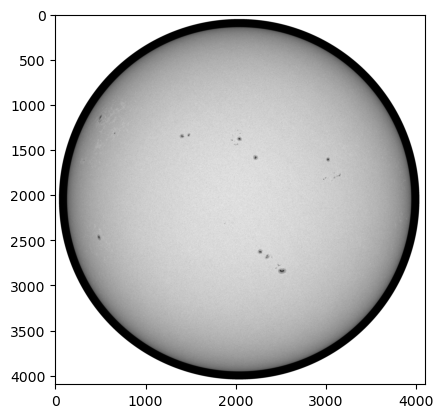

In [9]:
file_list = sorted(download_dir.glob('hmi.ic_45s.2026.04.*.continuum.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

## Download especif data of each sunstop

box(2449.7054,2851.0634,231.25,90.972222,0)

bottom_left: Tx=-265.60 arcsec, Ty=-425.72 arcsec
top_right:   Tx=-148.98 arcsec,  Ty=-380.01 arcsec


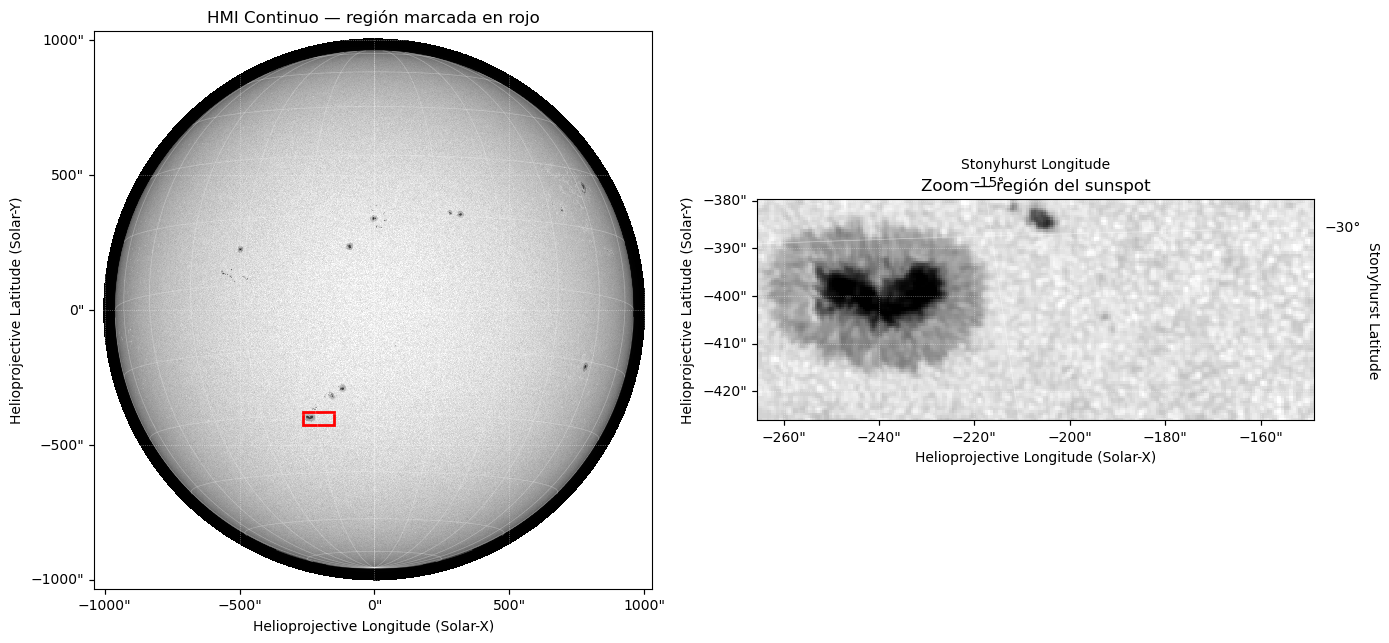

In [17]:
import sunpy.coordinates          # registra frames solares con astropy — no eliminar
import sunpy.map
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

# Cargar primer frame de continuo completo (ya descargado)
fits_file = download_dir / 'hmi.ic_45s.2026.04.01_12_01_30_TAI.continuum.fits'
hmi_map = sunpy.map.Map(str(fits_file))

# ── Región en píxeles DS9 (1-indexado, imagen sin rotar)
x_c_ds9 = 2449.7054   # centro pixel x en DS9
y_c_ds9 = 2851.0634   # centro pixel y en DS9
w_px    = 231.25       # ancho en píxeles
h_px    = 90.972222    # alto en píxeles

# Con CROTA2≈180° en HMI: Tx ∝ −pixel_x, Ty ∝ −pixel_y
#   → bottom_left en HPC (min Tx, min Ty) = max pixel x, max pixel y
#   → top_right   en HPC (max Tx, max Ty) = min pixel x, min pixel y
# DS9 usa indexado desde 1; Astropy desde 0  →  restar 1
x_bl = x_c_ds9 + w_px / 2 - 1   # max pixel x → min Tx
y_bl = y_c_ds9 + h_px / 2 - 1   # max pixel y → min Ty
x_tr = x_c_ds9 - w_px / 2 - 1   # min pixel x → max Tx
y_tr = y_c_ds9 - h_px / 2 - 1   # min pixel y → max Ty

bottom_left = hmi_map.wcs.pixel_to_world(x_bl, y_bl)
top_right   = hmi_map.wcs.pixel_to_world(x_tr, y_tr)

print(f"bottom_left: Tx={bottom_left.Tx:.2f}, Ty={bottom_left.Ty:.2f}")
print(f"top_right:   Tx={top_right.Tx:.2f},  Ty={top_right.Ty:.2f}")

# HMI tiene CROTA2≈180° (norte abajo en el FITS crudo); rotate() corrige la orientación
hmi_map_rot = hmi_map.rotate(order=3)

# ── Figura: disco completo con recuadro rojo + zoom de la región
fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection=hmi_map_rot)
hmi_map_rot.plot(axes=ax1, cmap='gray', clip_interval=(1, 99.9)*u.percent)
hmi_map_rot.draw_quadrangle(bottom_left, top_right=top_right,
                              edgecolor='red', linewidth=2)
hmi_map_rot.draw_grid(axes=ax1, color='white', alpha=0.3, lw=0.5)
ax1.set_title('HMI Continuo — región marcada en rojo')

region_map = hmi_map_rot.submap(bottom_left, top_right=top_right)
ax2 = fig.add_subplot(122, projection=region_map)
region_map.plot(axes=ax2, cmap='gray', clip_interval=(1, 99.9)*u.percent)
region_map.draw_grid(axes=ax2, color='white', alpha=0.5, lw=0.5)
ax2.set_title('Zoom — región del sunspot')

plt.tight_layout()
plt.show()


In [18]:
# tracking=True: el cutout sigue la rotación solar → la mancha queda centrada en toda la serie
# bottom_left y top_right definidos en la celda de visualización anterior
cutout = a.jsoc.Cutout(bottom_left, top_right=top_right, tracking=True)

# Búsqueda — un único frame para verificar
# Para 1 hora completa → a.Time('2026-04-01T12:00:00', '2026-04-01T13:00:00')
result_region = Fido.search(
    a.Time('2026-04-01T12:00:00', '2026-04-01T12:01:30'),
    a.jsoc.Series('hmi.Ic_45s'),
    a.jsoc.Notify('thomas.quamtum@gmail.com'),
    cutout,
)
print(result_region)


Results from 1 Provider:

3 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

         T_REC          TELESCOP  INSTRUME  WAVELNTH CAR_ROT
----------------------- -------- ---------- -------- -------
2026.04.01_12:00:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:01:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2309
2026.04.01_12:02:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2309




In [19]:
region_dir = pathlib.Path('../data/raw/sunspot_region')
region_dir.mkdir(parents=True, exist_ok=True)

files_region = Fido.fetch(result_region, path=region_dir)
print(files_region)

2026-05-19 20:14:17 - drms - INFO: Export request pending. [id=JSOC_20260520_001235, status=2]
2026-05-19 20:14:17 - drms - INFO: Waiting for 5 seconds...
2026-05-19 20:14:22 - drms - INFO: Export request pending. [id=JSOC_20260520_001235, status=1]
2026-05-19 20:14:22 - drms - INFO: Waiting for 10 seconds...
2026-05-19 20:14:33 - drms - INFO: Export request pending. [id=JSOC_20260520_001235, status=1]
2026-05-19 20:14:33 - drms - INFO: Waiting for 10 seconds...
2026-05-19 20:14:43 - drms - INFO: Export request pending. [id=JSOC_20260520_001235, status=1]
2026-05-19 20:14:43 - drms - INFO: Waiting for 10 seconds...
2026-05-19 20:14:54 - sunpy - INFO: 3 URLs found for download. Full request totaling 1MB


INFO: 3 URLs found for download. Full request totaling 1MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

hmi.ic_45s.20260401_120045_TAI.2.continuum.fits:   0%|          | 0.00/46.1k [00:00<?, ?B/s]

hmi.ic_45s.20260401_120130_TAI.2.continuum.fits:   0%|          | 0.00/46.1k [00:00<?, ?B/s]

hmi.ic_45s.20260401_120215_TAI.2.continuum.fits:   0%|          | 0.00/46.1k [00:00<?, ?B/s]

['../data/raw/sunspot_region/hmi.ic_45s.20260401_120045_TAI.2.continuum.fits', '../data/raw/sunspot_region/hmi.ic_45s.20260401_120130_TAI.2.continuum.fits', '../data/raw/sunspot_region/hmi.ic_45s.20260401_120215_TAI.2.continuum.fits']
